<div style='background: #0f1f3d; padding: 40px 48px 36px; border-radius: 6px;'>
  <p style='color: #5a9bd5; margin: 0 0 16px 0; font-size: 0.72em; letter-spacing: 3px; text-transform: uppercase; font-weight: 500;'>FARMSA Research Group &mdash; Module 1</p>
  <h1 style='color: #ffffff; font-size: 2em; font-weight: 600; margin: 0 0 6px 0; letter-spacing: -0.5px;'>Ledoit-Wolf Shrinkage</h1>
  <p style='color: #8fadc8; font-size: 0.95em; font-weight: 400; margin: 12px 0 0 0;'>Constant-correlation target &mdash; analytical optimal intensity</p>
</div>

## §1 Motivation & Derivation

### Motivation

The sample covariance matrix $S$ is unbiased but noisy. Its smallest eigenvalues are often underestimated, which causes a minimum-variance optimizer to concentrate heavily in assets that appear low-risk from the historical data. 

To stabilize the estimate, we shrink the sample covariance toward the simple matrix $F$ which assumes the same variance for every asset and no covariance:

$$
\hat{\Sigma}_{LW} = \alpha F + (1-\alpha) S
$$

Consider $\alpha$ as a dial:

- $\alpha = 0$ → trust the sample data entirely  
- $\alpha = 1$ → trust the structured model entirely  

The challenge is choosing the optimal shrinkage intensity $\alpha$.

---

### Intuition for the Optimal $\alpha$

Ledoit and Wolf choose $\alpha$ to make the estimator as close as possible to the true unknown covariance matrix $\Sigma$. They do this by minimizing the expected squared Frobenius error which is:

$$
\min_\alpha \; \mathbb{E}\left[\|\hat{\Sigma}_{LW} - \Sigma\|_F^2\right]
$$

Substituting the shrinkage estimator mentioned above

$$
\hat{\Sigma}_{LW} = \alpha F + (1-\alpha)S
$$

turns this into a quadratic optimization problem in $\alpha$. Solving it gives the expression

$$
\alpha^* = \frac{\pi - \rho}{T \gamma}
$$

where

| Quantity | Meaning |
|---|---|
| $\gamma = \|F-S\|_F^2$ | distance between the target and the sample covariance |
| $\pi$ | amount of estimation noise in the sample covariance |
| $\rho$ | correction for the fact that $F$ is estimated from the same data |
| $T$ | number of observations |

So,

- If the sample covariance matrix is very noisy, $\alpha$ increases and we shrink more toward $F$.
- If we have a lot of data, the sample covariance becomes reliable and $\alpha$ decreases.
- If the target $F$ is very different from the sample, shrinkage is smaller.

In practice this produces a small but stabilizing adjustment (for this dataset, $\alpha \approx 0.12$) which reduces extreme eigenvalues of the sample covariance matrix.

In [ ]:
# ── §2  Setup & Estimator ──────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# ── Load the shared universe (same 50 stocks for every module) ──
prices  = pd.read_csv('data/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)
N, T = returns.shape[1], returns.shape[0]
print(f"Loaded {N} assets × {T} days")


# ╔══════════════════════════════════════════════════════════╗
# ║  LEDOIT-WOLF SHRINKAGE  (constant-correlation target)   ║
# ╚══════════════════════════════════════════════════════════╝

def estimate_covariance(returns_df):
    """
    Ledoit-Wolf shrinkage toward the constant-correlation target.

    Parameters
    ----------
    returns_df : pd.DataFrame, shape (T, N)
        Daily simple returns.

    Returns
    -------
    Sigma_LW : np.ndarray, shape (N, N)
        Shrinkage covariance estimate: alpha*F + (1-alpha)*S.
    """
    R   = returns_df.values                     # T x N
    T_, N_ = R.shape

    # ── Sample covariance S ───────────────────────────────────
    mu  = R.mean(axis=0)                        # N
    X   = R - mu                                # demeaned returns, T x N
    S   = (X.T @ X) / (T_ - 1)                 # N x N

    # ── Constant-correlation target F ────────────────────────
    std      = np.sqrt(np.diag(S))              # N, asset volatilities
    corr_mat = S / np.outer(std, std)           # sample correlation matrix
    np.fill_diagonal(corr_mat, 1.0)

    # mean pairwise correlation (excludes diagonal)
    rho_bar = (corr_mat.sum() - N_) / (N_ * (N_ - 1))

    F = rho_bar * np.outer(std, std)            # off-diagonal: rho_bar * sigma_i * sigma_j
    np.fill_diagonal(F, np.diag(S))             # diagonal: keep sample variances

    # ── Analytical shrinkage intensity (Ledoit & Wolf 2004) ──

    # gamma: squared Frobenius norm ||F - S||^2
    gamma = np.sum((F - S) ** 2)

    # pi_ij = sample estimate of AVar(sqrt(T) * s_ij)
    #       = E[x_i^2 * x_j^2] - s_ij^2
    pi_mat = np.zeros((N_, N_))
    for i in range(N_):
        for j in range(N_):
            pi_mat[i, j] = np.mean(X[:, i]**2 * X[:, j]**2) - S[i, j]**2
    pi = pi_mat.sum()

    # rho: bias correction for the constant-correlation target
    rho_num = 0.0
    for i in range(N_):
        for j in range(N_):
            if i == j:
                # diagonal entries: rho_ii = pi_ii
                rho_num += pi_mat[i, i]
            else:
                beta_ij = (
                    S[j, j] * np.mean(X[:, i]**2 * X[:, j]**2)
                    - S[i, j] * np.mean(X[:, i] * X[:, j]**3)
                ) / (std[i] * std[j])
                beta_ji = (
                    S[i, i] * np.mean(X[:, j]**2 * X[:, i]**2)
                    - S[i, j] * np.mean(X[:, j] * X[:, i]**3)
                ) / (std[i] * std[j])
                rho_num += (rho_bar / 2) * (
                    (std[j] / std[i]) * beta_ij
                    + (std[i] / std[j]) * beta_ji
                )

    # optimal alpha, clipped to [0, 1]
    alpha = float(np.clip((pi - rho_num) / (T_ * gamma), 0.0, 1.0))

    # ── Shrinkage estimator ───────────────────────────────────
    Sigma_LW = alpha * F + (1.0 - alpha) * S
    return Sigma_LW


# ── Quick sanity check (don't remove) ──
cov_test = estimate_covariance(returns.iloc[:252])
assert cov_test.shape == (N, N), f"Expected ({N},{N}), got {cov_test.shape}"
assert np.allclose(cov_test, cov_test.T), "Not symmetric"
assert np.all(np.linalg.eigvalsh(cov_test) > -1e-10), "Negative eigenvalues"
print("✓ Estimator passes sanity checks")

# ── Spot-check: alpha and rho_bar on full sample ──
lw_full  = estimate_covariance(returns)
S_full   = returns.cov().values
std_full = np.sqrt(np.diag(S_full))
c_full   = S_full / np.outer(std_full, std_full)
np.fill_diagonal(c_full, 1.0)
rb_full  = (c_full.sum() - N) / (N * (N - 1))
print(f"Full-sample mean pairwise ρ̄ : {rb_full:.4f}")
print(f"Condition number  S  : {np.linalg.cond(S_full):.1f}")
print(f"Condition number  LW : {np.linalg.cond(lw_full):.1f}")

Loaded 50 assets × 1759 days
✓ Estimator passes sanity checks
Full-sample mean pairwise ρ̄ : 0.4032
Condition number  S  : 270.2
Condition number  LW : 198.8


In [20]:
# ── §3  Backtest ───────────────────────────────────────────
# We compare equal-weight, sample-covariance Mean Variance Optimizer (MVO), and LW-covariance MVO
# using a single estimation window and a non-rolling out-of-sample backtest.

def min_variance_portfolio(cov):
    """Minimum-variance portfolio (long-only, fully invested)."""
    n = cov.shape[0]
    w0 = np.ones(n) / n
    res = minimize(
        lambda w: w @ cov @ w,
        w0,
        method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
        options={'ftol': 1e-12, 'maxiter': 1000}
    )
    return res.x if res.success else w0

LOOKBACK = 252   # use first 1 year as estimation window
n = returns.shape[1]

# Split data into:
# - estimation period: first LOOKBACK days
# - test period: all remaining days
train = returns.iloc[:LOOKBACK]
test  = returns.iloc[LOOKBACK:]

# Estimate weights once
w_equal  = np.ones(n) / n
w_sample = min_variance_portfolio(train.cov().values)
w_lw     = min_variance_portfolio(estimate_covariance(train))

weights = {
    'Equal Weight': w_equal,
    'Sample Cov MVO': w_sample,
    'LW Estimator MVO': w_lw
}

# Run non-rolling backtest
pv = {k: [1.0] for k in weights}

for _, row in test.iterrows():
    day_ret = row.values
    for k in pv:
        pv[k].append(pv[k][-1] * (1 + weights[k] @ day_ret))

portfolio_df = pd.DataFrame(
    pv,
    index=[test.index[0] - pd.Timedelta(days=1)] + list(test.index)
)

print(f"✓ Non-rolling backtest complete — {len(test)} trading days")

✓ Non-rolling backtest complete — 1507 trading days


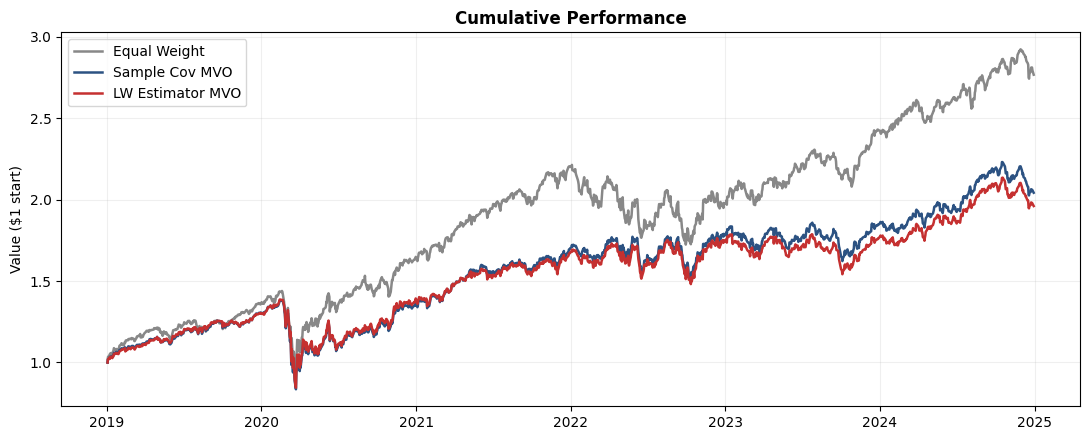

,Annualized Return,Annualized Volatility,Sharpe Ratio,Concentration (HHI)
Equal Weight,19.003,19.862,0.957,0.020
Sample Cov MVO,13.899,19.739,0.704,0.111
LW Estimator MVO,13.164,19.479,0.676,0.113


In [22]:
# ── §4  Results ────────────────────────────────────────────
C = {
    'Equal Weight': '#888',
    'Sample Cov MVO': '#2c5282',
    'LW Estimator MVO': '#c53030'
}

fig, ax = plt.subplots(figsize=(11, 4.5))
for k in portfolio_df.columns:
    ax.plot(portfolio_df.index, portfolio_df[k], label=k, color=C[k], lw=1.8)

ax.set_ylabel('Value ($1 start)')
ax.set_title('Cumulative Performance', fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Metrics
def metrics(v, w):
    r = v.pct_change().dropna()
    ar = r.mean() * 252
    av = r.std() * np.sqrt(252)
    sharpe = ar / av if av > 0 else 0
    hhi = np.sum(np.square(w))

    return {
        'Annualized Return': ar * 100,
        'Annualized Volatility': av * 100,
        'Sharpe Ratio': sharpe,
        'Concentration (HHI)': hhi
    }

results = pd.DataFrame({
    k: metrics(portfolio_df[k], weights[k])
    for k in portfolio_df.columns
}).T.round(3)

display(results)

## §5  Conclusion

### Did LW beat the sample covariance baseline?

The Ledoit–Wolf (LW) estimator produced slightly lower volatility (19.48% vs 19.74%) than the sample covariance portfolio, indicating a modest improvement in risk stability. However, the sample covariance portfolio achieved somewhat higher returns (13.90% vs 13.16%) and a slightly higher Sharpe ratio (0.70 vs 0.68). Overall, the performance difference between the two approaches is small.

### Why is the effect so small?

The shrinkage intensity is relatively small in this setting meaning the estimator remains very close to the sample covariance matrix. In our dataset, the amount of data available relative to the number of assets is fairly large, so the sample covariance matrix is already reasonably stable. As a result, shrinkage only makes small adjustments to the covariance estimates and therefore only slightly changes the optimized portfolio weights.